# Sweeping across ticks

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

# Keep the notebook clean from complex-step derivative warnings
warnings.filterwarnings("ignore")

In [18]:
months = ['201901', '201902', '201903']
merged_months = []

print("Loading and merging tick data...")

for m in months:
    # 1. Load the parquet files
    bid = pd.read_parquet(f"../data/processed/eurusd_dukascopy_bid_{m}.parquet")
    ask = pd.read_parquet(f"../data/processed/eurusd_dukascopy_ask_{m}.parquet")
    
    # 2. Ensure datetime format and sort (strictly required for merge_asof)
    bid['datetime'] = pd.to_datetime(bid['datetime'])
    ask['datetime'] = pd.to_datetime(ask['datetime'])
    bid = bid.sort_values('datetime')
    ask = ask.sort_values('datetime')
    
    # 3. Merge: Match every BID with the exact ASK active at that microsecond
    df_merged = pd.merge_asof(
        bid, 
        ask[['datetime', 'price']], 
        on='datetime', 
        direction='backward',
        suffixes=('_bid', '_ask')
    )
    
    # 4. Calculate Mid-Price and append
    df_merged['mid_price'] = (df_merged['price_bid'] + df_merged['price_ask']) / 2
    merged_months.append(df_merged)
    print(f"Processed {m}: {len(df_merged)} rows")

# 5. Combine into one master Q1 dataframe and set index
df_master = pd.concat(merged_months).reset_index(drop=True)
df_master.set_index('datetime', inplace=True)
print(f"\nTotal Q1 Ticks Ready: {len(df_master)}")

Loading and merging tick data...
Processed 201901: 3477166 rows
Processed 201902: 2740372 rows
Processed 201903: 2755889 rows

Total Q1 Ticks Ready: 8973427


In [19]:
def sweep_tick_windows(df_raw, windows):
    results = []
    
    for window in windows:
        print(f"Fitting {window}-tick window...")
        
        # 1. Sample using mid_price to avoid bid-ask bounce noise
        df_sampled = df_raw.iloc[::window].copy()
        df_sampled['log_returns'] = np.log(df_sampled['mid_price'] / df_sampled['mid_price'].shift(1))
        df_sampled.dropna(inplace=True)
        
        # 2. Fit Model
        model = sm.tsa.MarkovRegression(
            endog=df_sampled['log_returns'], 
            k_regimes=2, 
            trend='c', 
            switching_trend=False, 
            switching_variance=True
        )
        
        try:
            res = model.fit(disp=False)
            
            # 3. Extract variances (ensure Regime 0 is low vol, Regime 1 is high vol)
            variances = sorted([res.params[f'sigma2[{i}]'] for i in range(2)])
            var_ratio = variances[1] / variances[0]
            
            # 4. Extract transition probabilities for the High Vol regime
            high_vol_idx = 1 if res.params['sigma2[1]'] > res.params['sigma2[0]'] else 0
            
            # FIX: statsmodels only outputs p[0->0] and p[1->0]
            if high_vol_idx == 0:
                p_high_to_high = res.params['p[0->0]']
            else:
                p_high_to_high = 1.0 - res.params['p[1->0]']
            
            # 5. Calculate Expected Duration
            duration_bars = 1 / (1 - p_high_to_high)
            duration_ticks = duration_bars * window
            
            results.append({
                'Tick Window': window,
                'Observations': len(df_sampled),
                'Variance Ratio (High/Low)': round(var_ratio, 2),
                'High Vol Duration (Bars)': round(duration_bars, 1),
                'High Vol Duration (Total Ticks)': round(duration_ticks, 0)
            })
            
        except Exception as e:
            print(f"Window {window} failed: {e}")
            
    return pd.DataFrame(results)

In [20]:
# Because we have 3 months of data, we can afford to test much larger windows
# A 10,000 tick window might reveal massive macroeconomic shifts
windows_to_test = [10, 100, 500, 1000, 2500, 5000, 10000, 10000] 

print("Starting parameter sweep...")
sweep_results = sweep_tick_windows(df_master, windows_to_test)

print("\n--- Q1 2019 Regime Sweep Results ---")
print(sweep_results.to_string(index=False))

Starting parameter sweep...
Fitting 10-tick window...
Window 10 failed: Steady-state probabilities could not be constructed.
Fitting 100-tick window...
Fitting 500-tick window...
Fitting 1000-tick window...
Fitting 2500-tick window...
Fitting 5000-tick window...
Fitting 10000-tick window...
Fitting 10000-tick window...

--- Q1 2019 Regime Sweep Results ---
 Tick Window  Observations  Variance Ratio (High/Low)  High Vol Duration (Bars)  High Vol Duration (Total Ticks)
         100         89734                       4.73                      12.7                           1273.0
         500         17946                       4.89                       9.2                           4613.0
        1000          8973                       5.85                       5.0                           4969.0
        2500          3589                       6.49                       3.3                           8350.0
        5000          1794                       7.06                       

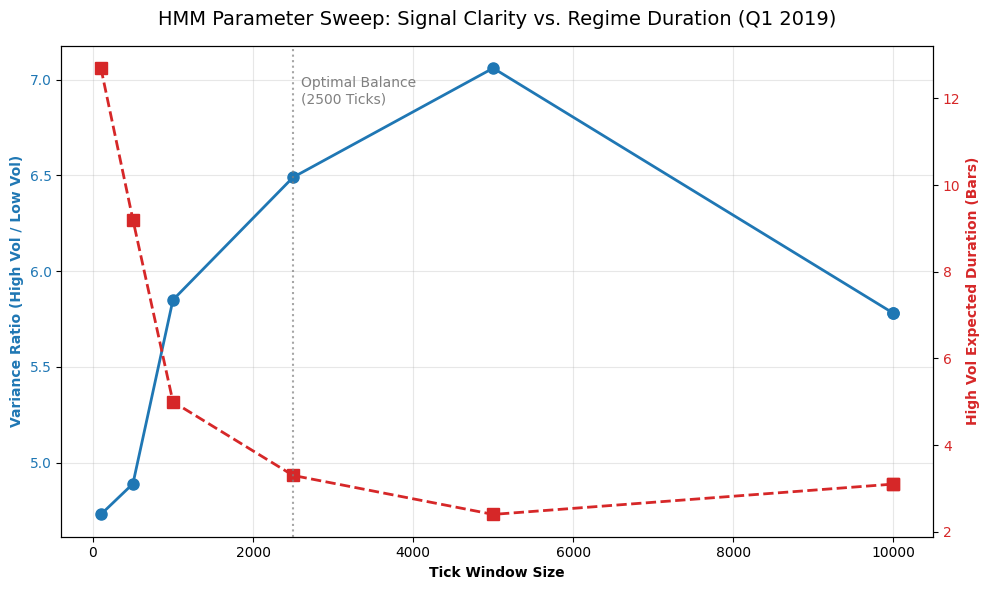

In [21]:
import matplotlib.pyplot as plt

# Create the figure and the first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Plot 1: Signal Clarity (Left Y-Axis) ---
color1 = 'tab:blue'
ax1.set_xlabel('Tick Window Size', fontweight='bold')
ax1.set_ylabel('Variance Ratio (High Vol / Low Vol)', color=color1, fontweight='bold')
ax1.plot(sweep_results['Tick Window'], sweep_results['Variance Ratio (High/Low)'], 
         marker='o', color=color1, linewidth=2, markersize=8, label='Variance Ratio')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()

# --- Plot 2: Regime Duration (Right Y-Axis) ---
color2 = 'tab:red'
ax2.set_ylabel('High Vol Expected Duration (Bars)', color=color2, fontweight='bold')
ax2.plot(sweep_results['Tick Window'], sweep_results['High Vol Duration (Bars)'], 
         marker='s', color=color2, linewidth=2, linestyle='--', markersize=8, label='Duration (Bars)')
ax2.tick_params(axis='y', labelcolor=color2)

# --- Formatting ---
plt.title('HMM Parameter Sweep: Signal Clarity vs. Regime Duration (Q1 2019)', fontsize=14, pad=15)
fig.tight_layout()

# Optional: Add vertical line for the "Sweet Spot" we discussed
plt.axvline(x=2500, color='gray', linestyle=':', alpha=0.7)
plt.text(2600, ax2.get_ylim()[1]*0.9, 'Optimal Balance\n(2500 Ticks)', color='gray')

plt.show()